In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
sns.set_style('whitegrid')

In [2]:
df = pd.read_csv(
    r'C:\Users\HP\Downloads\Data Analytics Projects\Final Projects\Telecom_Churn_Analysis\outputs\segmented_customers.csv'
)

In [3]:
df.head()

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason,Tenure Groups,Risk Level,Churned_Flag,Cluster,Customer_Segmentation
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,...,381.51,974.81,Stayed,NaN,NaN,0-12 Months,Low Risk,0,2,Low Value Customers
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,...,96.21,610.28,Stayed,NaN,NaN,0-12 Months,Low Risk,0,0,High Value Customers
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,...,134.60,415.45,Churned,Competitor,Competitor had better devices,0-12 Months,High Risk,1,2,Low Value Customers
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,...,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction,13-24 Months,High Risk,1,2,Low Value Customers
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,...,22.14,289.54,Churned,Dissatisfaction,Network reliability,0-12 Months,High Risk,1,2,Low Value Customers


In [4]:
#top churn reasons 
top_reasons = df[
   df['Customer Status'] == 'Churned'
]['Churn Reason'].value_counts().head(10)
print(top_reasons)

Churn Reason
Competitor had better devices                313
Competitor made better offer                 311
Attitude of support person                   220
Don't know                                   130
Competitor offered more data                 117
Competitor offered higher download speeds    100
Attitude of service provider                  94
Price too high                                78
Product dissatisfaction                       77
Network reliability                           72
Name: count, dtype: int64


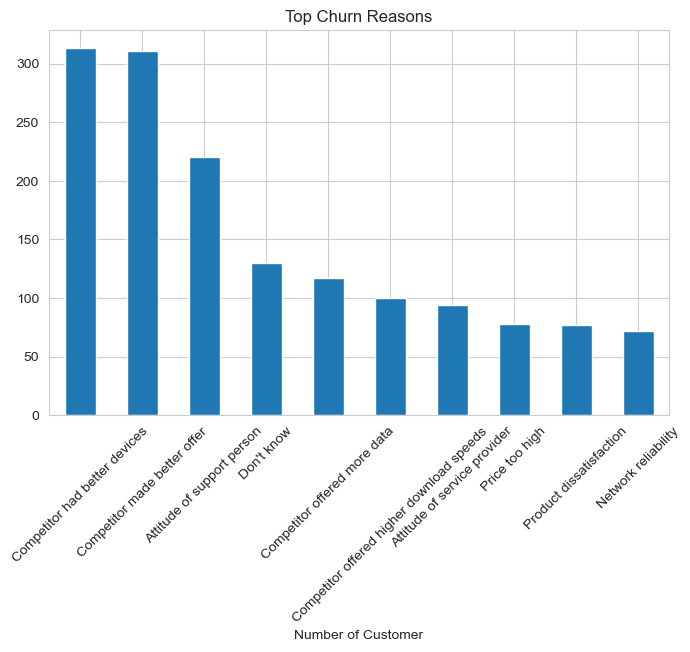

In [5]:
#Visualize Churn Reasons 
plt.figure(figsize = (8,5))
top_reasons.plot(kind = 'bar')
plt.title('Top Churn Reasons')
plt.xlabel('Number of Customer')
plt.xticks(rotation = 45)
plt.show()

#Competitors pricing and devive - related disatisfactio are major churn drives 

In [8]:
#Revenue Loss 
revenue_loss = df[
   df['Customer Status'] == 'Churned'
]['Monthly Charge'].sum()
print(revenue_loss)

137086.65


In [10]:
high_risk_customers = df[
    (df['Contract'] == 'Month-to-Month') &
    (df['Internet Type'] == 'Fiber Optic') &
    (df['Customer Status'] == 'Churned')
]

high_risk_customers.head()

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason,Tenure Groups,Risk Level,Churned_Flag,Cluster,Customer_Segmentation
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,...,134.60,415.45,Churned,Competitor,Competitor had better devices,0-12 Months,High Risk,1,2,Low Value Customers
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,...,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction,13-24 Months,High Risk,1,2,Low Value Customers
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,...,22.14,289.54,Churned,Dissatisfaction,Network reliability,0-12 Months,High Risk,1,2,Low Value Customers
21,0023-XUOPT,Female,26,Yes,0,Carnelian Bay,96140,39.227434,-120.091806,1,...,566.28,1781.88,Churned,Other,Don't know,13-24 Months,High Risk,1,2,Low Value Customers
53,0093-XWZFY,Male,51,No,0,Desert Hot Springs,92241,33.832799,-116.250973,0,...,1507.60,5544.45,Churned,Competitor,Competitor had better devices,25-48 Months,High Risk,1,1,Medium value Customer


In [11]:
print(f'Total High Risk Customers: {high_risk_customers.shape[0]}')

Total High Risk Customers: 1107


In [14]:
segment_churn = pd.crosstab(
    df['Customer_Segmentation'],
    df['Customer Status']
)

print(segment_churn)

Customer Status        Churned  Joined  Stayed
Customer_Segmentation                         
High Value Customers       277     222    1684
Low Value Customers       1256     232    1198
Medium value Customer      336       0    1838


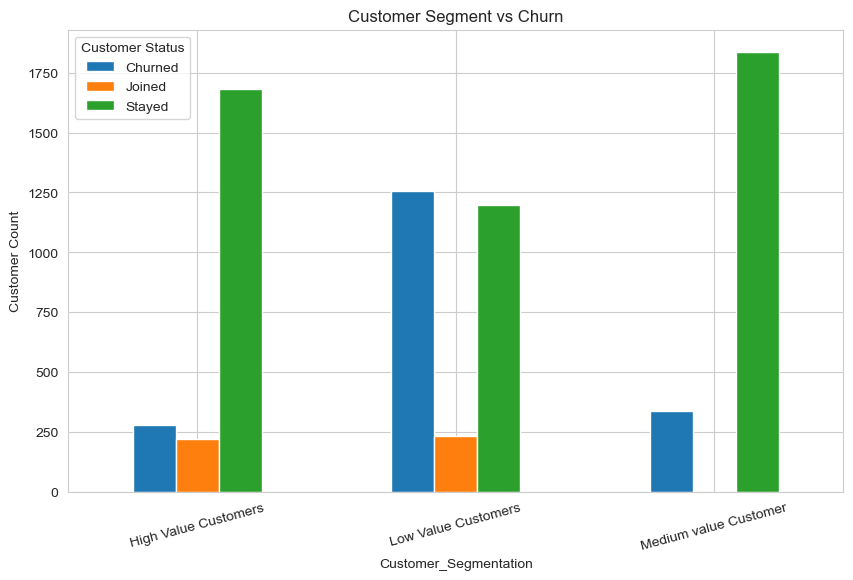

In [15]:
segment_churn.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Customer Segment vs Churn')

plt.ylabel('Customer Count')

plt.xticks(rotation=15)

plt.show()

In [17]:
segment_revenue = df.groupby(
    'Customer_Segmentation'
)['Monthly Charge'].sum()

print(segment_revenue)

Customer_Segmentation
High Value Customers      53215.50
Low Value Customers      200190.80
Medium value Customer    194501.25
Name: Monthly Charge, dtype: float64


In [19]:
# Business Recommendations

#1. Prioritize Month-to-Month customers for retention campaigns.

#2. Improve Fiber Optic service quality and customer support.

#3. Offer long-term contract discounts to reduce churn probability.

#4. Target customers within first 12 months because early-stage churn is highest.

#5. High-value customers should receive loyalty rewards and personalized offers.